In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
from skopt import gp_minimize
from skopt.space import Integer, Real, Categorical
from skopt.utils import use_named_args
import matplotlib.pyplot as plt

In [2]:
# Create a sample dataset
X, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=15, 
    n_redundant=5, 
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
# Define the hyperparameter search space
dimensions = [
    Integer(10, 100, name='n_estimators'),           # Number of trees
    Integer(1, 20, name='max_depth'),                # Maximum tree depth
    Integer(2, 20, name='min_samples_split'),        # Min samples to split (must be >= 2)
    Integer(1, 10, name='min_samples_leaf'),         # Min samples in leaf
    Real(0.1, 1.0, name='max_features'),             # Fraction of features to consider
    Categorical(['gini', 'entropy'], name='criterion') # Split criterion
]

In [4]:
# Define the objective function to minimize (we'll minimize negative accuracy)
@use_named_args(dimensions)
def objective(**params):
    # Create model with current hyperparameters
    model = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        criterion=params['criterion'],
        random_state=42,
        n_jobs=-1
    )
    
    # Use cross-validation to evaluate performance
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    
    # Return negative mean CV score (since we minimize)
    return -np.mean(cv_scores)

In [5]:
# Run Bayesian Optimization
print("Starting Bayesian Optimization...")
print("This will evaluate different hyperparameter combinations...")

result = gp_minimize(
    func=objective,
    dimensions=dimensions,
    n_calls=30,  # Number of evaluations (reduced for faster execution)
    n_initial_points=5,  # Random evaluations before using GP
    random_state=42
)

Starting Bayesian Optimization...
This will evaluate different hyperparameter combinations...


In [6]:
# Get the best hyperparameters
best_params = {
    'n_estimators': result.x[0],
    'max_depth': result.x[1],
    'min_samples_split': result.x[2],
    'min_samples_leaf': result.x[3],
    'max_features': result.x[4],
    'criterion': result.x[5]
}

print(f"\nBest hyperparameters found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest cross-validation score: {-result.fun:.4f}")


Best hyperparameters found:
  n_estimators: 100
  max_depth: 16
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.1
  criterion: gini

Best cross-validation score: 0.8937


In [7]:
# Train final model with best parameters
best_model = RandomForestClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=16, max_features=0.1, random_state=42)

In [8]:
# Evaluate on test set
test_accuracy = accuracy_score(y_test, best_model.predict(X_test))
print(f"Test set accuracy: {test_accuracy:.4f}")

Test set accuracy: 0.9000


In [9]:
# Compare with default parameters
default_model = RandomForestClassifier(random_state=42)
default_model.fit(X_train, y_train)
default_accuracy = accuracy_score(y_test, default_model.predict(X_test))
print(f"Default parameters test accuracy: {default_accuracy:.4f}")
print(f"Improvement: {test_accuracy - default_accuracy:.4f}")

Default parameters test accuracy: 0.9000
Improvement: 0.0000


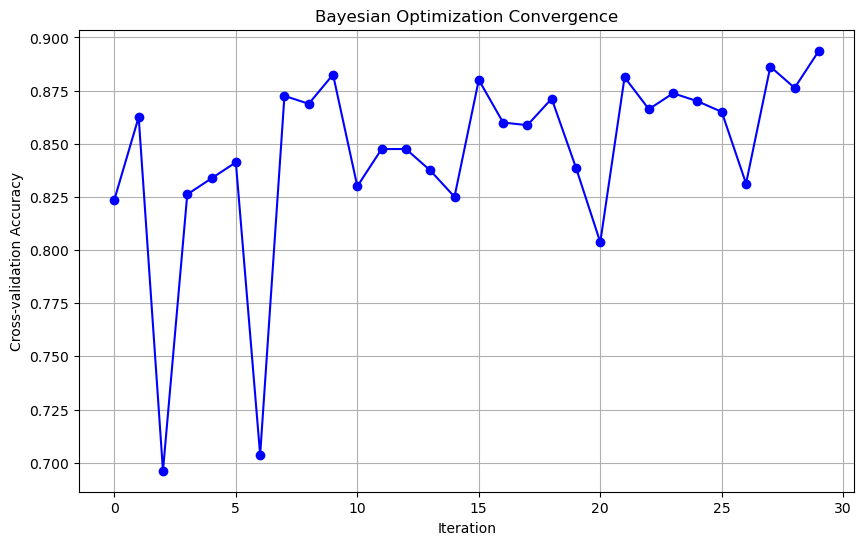

In [10]:
# Plot convergence
try:
    plt.figure(figsize=(10, 6))
    plt.plot([-score for score in result.func_vals], 'bo-')
    plt.xlabel('Iteration')
    plt.ylabel('Cross-validation Accuracy')
    plt.title('Bayesian Optimization Convergence')
    plt.grid(True)
    plt.show()
except Exception as e:
    print(f"Plotting error: {e}")

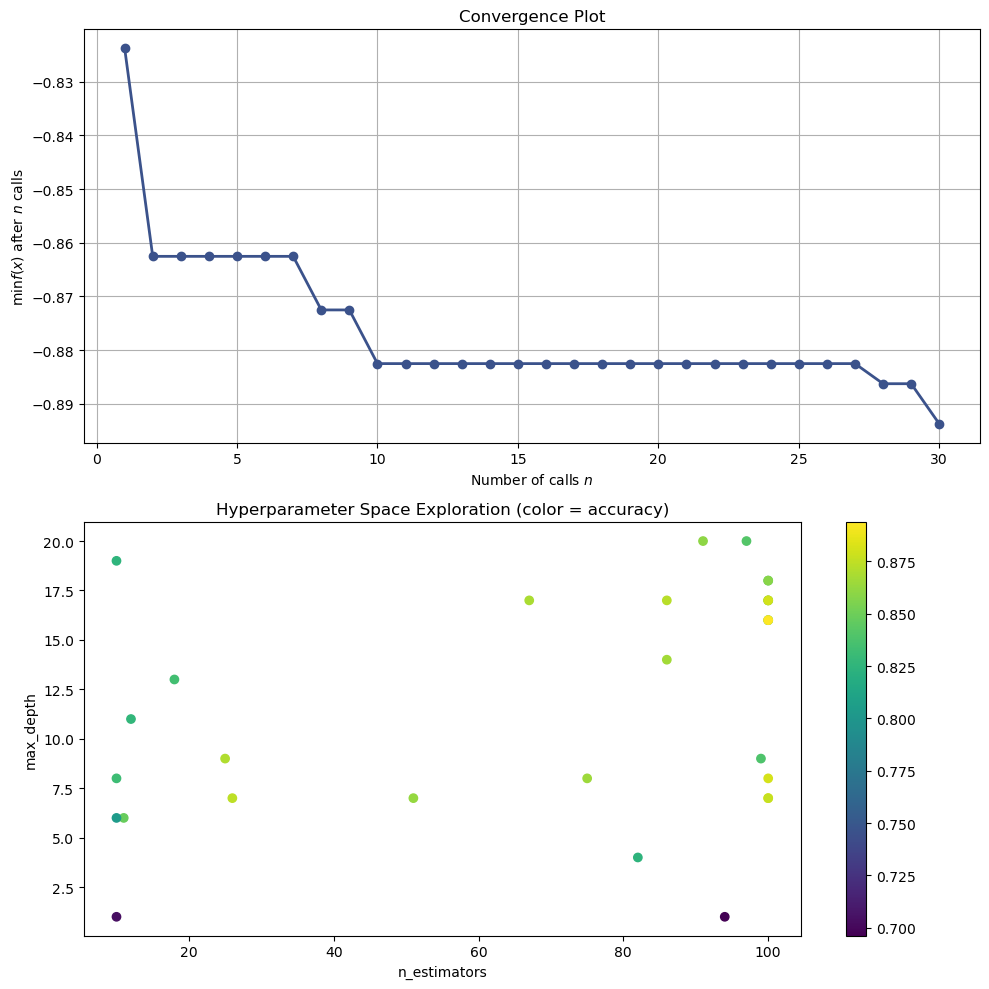


Key benefits of Bayesian Optimization:
1. Efficient: Only 50 evaluations vs 100,000+ for grid search
2. Adaptive: Learns from previous evaluations to make smarter choices
3. Handles mixed parameter types: continuous, discrete, categorical
4. Provides uncertainty estimates about parameter importance


In [11]:
# Show acquisition function behavior (for the last few iterations)
try:
    from skopt.plots import plot_convergence
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 10))
    
    # Convergence plot
    plot_convergence(result, ax=axes[0])
    axes[0].set_title('Convergence Plot')
    
    # Show how often each hyperparameter value was tried
    evaluated_points = result.x_iters
    n_estimators_tried = [point[0] for point in evaluated_points]
    max_depth_tried = [point[1] for point in evaluated_points]
    
    scatter = axes[1].scatter(n_estimators_tried, max_depth_tried, 
                            c=[-score for score in result.func_vals], cmap='viridis')
    axes[1].set_xlabel('n_estimators')
    axes[1].set_ylabel('max_depth')
    axes[1].set_title('Hyperparameter Space Exploration (color = accuracy)')
    plt.colorbar(scatter, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("skopt.plots not available, skipping advanced plots")
except Exception as e:
    print(f"Plotting error: {e}")

print("\nKey benefits of Bayesian Optimization:")
print("1. Efficient: Only 50 evaluations vs 100,000+ for grid search")
print("2. Adaptive: Learns from previous evaluations to make smarter choices")
print("3. Handles mixed parameter types: continuous, discrete, categorical")
print("4. Provides uncertainty estimates about parameter importance")